In [5]:
import sys
!{sys.executable} -m pip install spacy

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.



  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached typer-0.26.7-py3-none-any.whl.metadata (16 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached cloudpathlib-0.24.0-py3-none-any.whl.metadata (16 kB)
   ---------------------------------------- 0.0/14.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.2 MB 4.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.8/14.2 MB 4.8 MB/s eta 0:00:03
   --------- ----------------------------

In [7]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 13.1 MB/s eta 0:00:01
     ----------------- ---------------------- 5.5/12.8 MB 15.3 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 15.0 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.8 MB 15.4 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 14.1 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [9]:
import spacy
import pandas as pd
import json
import re

nlp = spacy.load("en_core_web_sm")
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [13]:
import os
print(os.getcwd())

C:\Users\annwe


In [15]:
import os
print(os.path.exists(r"C:\Users\annwe\Desktop\project 3 skills extractor\data\sample_profiles.txt"))

True


In [17]:
with open(r"C:\Users\annwe\Desktop\project 3 skills extractor\data\sample_profiles.txt", "r") as f:
    raw_text = f.read()

profiles = re.split(r'---PROFILE_\d+---', raw_text)
profiles = [p.strip() for p in profiles if p.strip()]

print(f"Loaded {len(profiles)} profiles.")
for i, p in enumerate(profiles):
    print(f"\nProfile {i+1} preview: {p[:80]}...")

Loaded 5 profiles.

Profile 1 preview: I am an HR professional with five years of experience in talent acquisition and ...

Profile 2 preview: I work as a data analyst with a focus on people analytics. I have built Python s...

Profile 3 preview: I am a project manager with experience leading cross-functional teams in the tec...

Profile 4 preview: I specialize in learning and development. I have designed e-learning modules, co...

Profile 5 preview: I am a generalist HR professional with experience in employee relations, HR poli...


In [21]:
onet_df = pd.read_csv(r"C:\Users\annwe\Desktop\project 3 skills extractor\data\onet_skills.csv")
print(onet_df.shape)
onet_df.head()

(15, 3)


,onet_code,skill_name,keywords
0,2.B.1.a,Reading Comprehension,"reading, comprehension, understanding documents"
1,2.B.1.b,Active Listening,"listening, communication, facilitating"
2,2.B.1.c,Writing,"writing, documentation, drafting, policy"
3,2.B.1.d,Speaking,"presenting, speaking, facilitation, workshops"
4,2.B.2.e,Critical Thinking,"analysis, problem solving, decision making, as..."


In [23]:
def extract_skills(profile_text, onet_df):
    doc = nlp(profile_text.lower())
    
    # Extract noun chunks (phrases like "talent acquisition", "data analysis")
    noun_phrases = [chunk.text.strip() for chunk in doc.noun_chunks if len(chunk.text.strip()) > 3]
    
    matched_skills = []
    
    for _, row in onet_df.iterrows():
        keywords = [k.strip().lower() for k in row['keywords'].split(',')]
        
        matched_signal = None
        for phrase in noun_phrases:
            for keyword in keywords:
                if keyword in phrase or phrase in keyword:
                    matched_signal = phrase
                    break
            if matched_signal:
                break
        
        # Also do a direct text scan as backup
        if not matched_signal:
            for keyword in keywords:
                if keyword in profile_text.lower():
                    matched_signal = keyword
                    break
        
        if matched_signal:
            matched_skills.append({
                "skill_name": row['skill_name'],
                "onet_code": row['onet_code'],
                "source_signal": matched_signal,
                "hris_visibility": "likely not captured",
                "gap_flag": True
            })
    
    return matched_skills

# Test on Profile 1
test_result = extract_skills(profiles[0], onet_df)
print(f"Skills found in Profile 1: {len(test_result)}")
for s in test_result:
    print(f"  → {s['skill_name']} ({s['onet_code']}) | signal: '{s['source_signal']}'")

Skills found in Profile 1: 9
  → Active Listening (2.B.1.b) | signal: 'facilitating'
  → Speaking (2.B.1.d) | signal: 'training workshops'
  → Active Learning (2.B.3.a) | signal: 'training workshops'
  → Monitoring (2.B.4.a) | signal: 'performance appraisal cycles'
  → Administration and Management (2.C.1.a) | signal: 'onboarding'
  → Personnel and Human Resources (2.C.2.a) | signal: 'an hr'
  → Mathematics (2.C.3.c) | signal: 'workforce analytics dashboards'
  → Computers and Electronics (2.C.4.b) | signal: 'excel'
  → Education and Training (2.C.9.a) | signal: 'training workshops'


In [25]:
all_results = []

for i, profile in enumerate(profiles):
    profile_id = f"P00{i+1}"
    matched = extract_skills(profile, onet_df)
    
    all_results.append({
        "profile_id": profile_id,
        "total_skills_detected": len(matched),
        "matched_skills": matched
    })
    
    print(f"{profile_id}: {len(matched)} skills detected")

# Save to JSON
with open(r"C:\Users\annwe\Desktop\project 3 skills extractor\output\extracted_skills.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\nSaved to output/extracted_skills.json")

P001: 9 skills detected
P002: 5 skills detected
P003: 6 skills detected
P004: 4 skills detected
P005: 4 skills detected

Saved to output/extracted_skills.json


  Profile  Skills Detected  Typical HRIS Captures
0    P001                9                      3
1    P002                5                      3
2    P003                6                      3
3    P004                4                      3
4    P005                4                      3


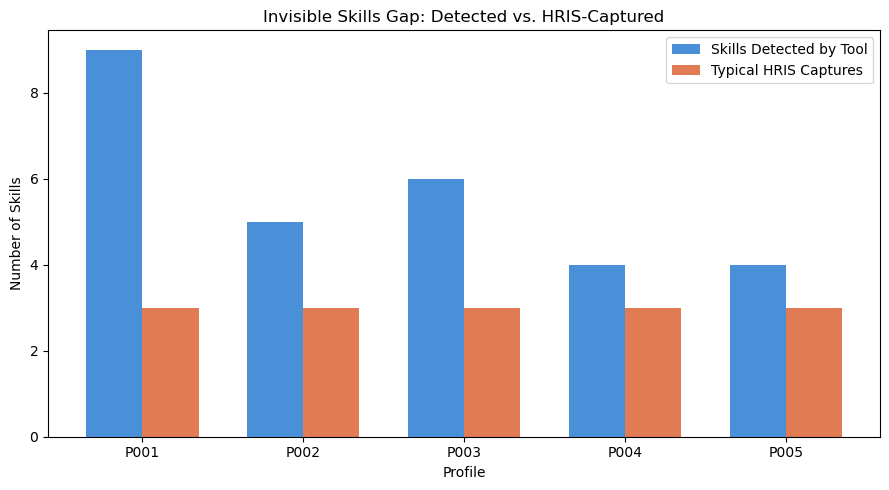

In [31]:
import matplotlib.pyplot as plt

summary = pd.DataFrame([{
    "Profile": r["profile_id"],
    "Skills Detected": r["total_skills_detected"],
    "Typical HRIS Captures": 3  # conservative estimate — hardcoded for prototype
} for r in all_results])

print(summary)

# Bar chart
x = range(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], summary["Skills Detected"], width, label="Skills Detected by Tool", color="#4A90D9")
bars2 = ax.bar([i + width/2 for i in x], summary["Typical HRIS Captures"], width, label="Typical HRIS Captures", color="#E07B54")

ax.set_xlabel("Profile")
ax.set_ylabel("Number of Skills")
ax.set_title("Invisible Skills Gap: Detected vs. HRIS-Captured")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["Profile"])
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\annwe\Desktop\project 3 skills extractor\output\skills_gap_chart.png", dpi=150)
plt.show()

In [33]:
rows = []
for r in all_results:
    for skill in r["matched_skills"]:
        rows.append({
            "Profile ID": r["profile_id"],
            "Skill Name": skill["skill_name"],
            "O*NET Code": skill["onet_code"],
            "Source Signal": skill["source_signal"],
            "HRIS Visibility": skill["hris_visibility"]
        })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(r"C:\Users\annwe\Desktop\project 3 skills extractor\output\skills_summary.csv", index=False)
print(f"Exported {len(summary_df)} skill matches to CSV.")
summary_df.head(10)

Exported 28 skill matches to CSV.


,Profile ID,Skill Name,O*NET Code,Source Signal,HRIS Visibility
0,P001,Active Listening,2.B.1.b,facilitating,likely not captured
1,P001,Speaking,2.B.1.d,training workshops,likely not captured
2,P001,Active Learning,2.B.3.a,training workshops,likely not captured
3,P001,Monitoring,2.B.4.a,performance appraisal cycles,likely not captured
4,P001,Administration and Management,2.C.1.a,onboarding,likely not captured
5,P001,Personnel and Human Resources,2.C.2.a,an hr,likely not captured
6,P001,Mathematics,2.C.3.c,workforce analytics dashboards,likely not captured
7,P001,Computers and Electronics,2.C.4.b,excel,likely not captured
8,P001,Education and Training,2.C.9.a,training workshops,likely not captured
9,P002,Administration and Management,2.C.1.a,workforce planning decisions,likely not captured
